# 15 — two histograms and no polarisation

The smallest experiment this model still accepts: one labelled sample, one
laser, two detectors, and no polarising beam splitter -- the emission is
collected at the magic angle, where the anisotropy term is multiplied by zero.

It is here to show what the identifiability table is *for*. Seven unknowns
describe rotation and polarised detection, and this experiment measures none of
them. The table says so before the fit runs, and the fit will nonetheless print
a number for all seven, because a Bayesian fit always prints a number: it is
the prior.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import experiment as X
from bd import P                      # the prototype, for the measured deviance reference


## The description


In [2]:
exp = X.magic_angle_minimal()
print(exp.summary())


magic angle, labelled sample only: 2 histograms
  samples     DA (donor+acceptor)
  excitations green at 0 ns, reaches donor x 1.0, acceptor x EX_AG
  detectors   g (green), r (red)
  histograms
    DA  g_ma     magic         donor + FRET + sensitised acceptor + acceptor directly (EX_AG)
    DA  r_ma     magic         donor + FRET + sensitised acceptor + acceptor directly (EX_AG)
  no polarisation: the anisotropy is not measured here


The same description as JSON — this is what you would keep beside the data, and
what a program other than this notebook would read.


In [3]:
print(exp.to_json()[:700] + '\n...')
assert X.Experiment.from_json(exp.to_json()).to_dict() == exp.to_dict()


{
  "name": "magic angle, labelled sample only",
  "notes": "no polarisation: the anisotropy is not measured here",
  "interleaved": false,
  "samples": [
    {
      "name": "DA",
      "carries": [
        "donor",
        "acceptor"
      ]
    }
  ],
  "excitations": [
    {
      "name": "green",
      "excites": {
        "donor": 1.0,
        "acceptor": "EX_AG"
      },
      "delay_ns": 0.0
    }
  ],
  "detectors": [
    {
      "name": "g",
      "colour": "green"
    },
    {
      "name": "r",
      "colour": "red"
    }
  ],
  "channels": [
    {
      "sample": "DA",
      "excitation": "green",
      "detector": "g",
      "polarisation": "magic"
    },
    {
      "sample": 
...


## What this experiment can and cannot determine

Before fitting anything. Each unknown is moved and the change in every
histogram measured; the share is how much of what the posterior will say comes
from the data rather than from the prior. **A share near zero is conclusive**:
nothing in the data moves, so whatever the fit prints for it is the prior. A
share near one is not conclusive — this is the diagonal, and a coordinate can
still be undetermined through a correlation.


In [4]:
model = X.build(exp, knots=25)
rows = X.identifiability(exp, model)
print(f'{"unknown":<16}{"group":<7}{"data share":>11}   carried by')
for r in sorted(rows, key=lambda r: r['data_share'])[:12]:
    print(f'{r["variable"]:<16}{r["role"]:<7}{r["data_share"]:>11.4f}   {r["carried_by"]}')
blind = X.unidentified(rows)
print(f'\n{len(blind)} of {len(rows)} unknowns are moved by nothing in these data:')
print('  ' + ', '.join(r['variable'] for r in blind))


  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
unknown         group   data share   carried by
log10_lam       hyper       0.0000   nothing
w_rho           phys        0.0000   nothing
w_rho_a         phys        0.0000   nothing
r0_d            phys        0.0000   nothing
r0_a            phys        0.0000   nothing
g               cal         0.0000   nothing
l1              cal         0.0000   nothing
l2              cal         0.0000   nothing
C_GA            cal         0.9596   DA g_ma
C_RA            cal         0.9924   DA r_ma
C_GD            cal         0.9928   DA g_ma
C_RD            cal         0.9946   DA r_ma

8 of 28 unknowns are moved by nothing in these data:
  log10_lam, w_rho, w_rho_a, r0_d, r0_a, g, l1, l2


## Data from that description

A mixture of two populations, one at $R/R_0 = 0.85$ and a broader one at 1.25,
simulated through the same forward model the fit uses and given Poisson noise.
No bursts and no selection: this is the idealised measurement, so that anything
the fit gets wrong is the *inference's* fault and not the experiment's.


In [5]:
rel = model['rel']
p_true = (np.exp(-0.5 * ((rel - 0.85) / 0.07) ** 2)
          + 0.6 * np.exp(-0.5 * ((rel - 1.25) / 0.09) ** 2))
p_true = p_true / p_true.sum()
y, lam_true, vals = X.simulate(exp, model, p_true, photons=3e5, seed=1)
for k in model['keys']:
    print(f'{k[0]:<3} {k[1]:<8} {float(y[k].sum()):>10,.0f} photons')


DA  g_ma        308,880 photons
DA  r_ma        346,973 photons


## The fit

The roughness weight of the P-spline prior on $\log p(R/R_0)$ is not maximised
but integrated out: a Laplace approximation at each node of a grid, the nodes
mixed by their evidences.


In [6]:
import time
t0 = time.time()
g, post = X.fit(exp, model, y, lam_nodes=(1.0, 0.0, -1.0))
print(f'{time.time() - t0:.0f} s')


/Users/tpeulen/mambaforge/envs/arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/s88_laplace_posterior.py:2933: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  evid = -float(f2) + 0.5 * graph.dim * math.log(2 * math.pi) - 0.5 * logdet


77 s


## Rule 0

No number about a fitted quantity is reportable without the weighted residuals
and the fit statistic. The Poisson deviance per degree of freedom is compared
with a **measured** reference and not with 1: the deviance of a correct model
at these counts is close to the number of *bins*, while the reported degrees of
freedom subtract the whole parameter dimension even though a penalised spline
uses far fewer of them. So the reference is Poisson draws at the fitted means.


In [7]:
ref_mean, ref_sd = P.poisson_reference(post, n_draw=200, seed=0)
print(f'{"histogram":<14}{"photons":>12}{"D/dof":>9}{"runs p":>9}')
for r in X.rule0(model, g, post, y):
    print(f'{r["channel"]:<14}{r["counts"]:>12,.0f}{r["dpd"]:>9.3f}{r["runs_p"]:>9.3f}')
z = (post['dev'] / post['dof'] - ref_mean) / ref_sd
print(f'\nreference D/dof (Poisson draws at the fitted means): {ref_mean:.3f} +- {ref_sd:.3f}')
print(f'this fit: {post["dev"] / post["dof"]:.3f}, which is {z:+.1f} reference sd')
print('VERDICT:', 'passes' if abs(z) < 3 else 'FAILS -- this result is excluded and counted')


histogram          photons    D/dof   runs p
DA g_ma            308,880    1.295    0.725
DA r_ma            346,973    1.487    0.384
all                655,853    1.391      nan

reference D/dof (Poisson draws at the fitted means): 1.579 +- 0.133
this fit: 1.391, which is -1.4 reference sd
VERDICT: passes


In [8]:
ks = list(g.data_keys)
n = len(ks)
fig, axes = plt.subplots(2, n, figsize=(3.4 * n, 5.0), sharex=True,
                         gridspec_kw=dict(height_ratios=[2.2, 1.0]))
axes = np.atleast_2d(axes).reshape(2, n)
tc = model['Eu']['tc']; wid = model['Eu']['wid']
for j, k in enumerate(ks):
    a, ar = axes[0, j], axes[1, j]
    yk = np.asarray(y[k]); lk = np.asarray(post['lam'][k])
    a.semilogy(tc, np.maximum(yk, 0.3) / wid, 'k.', ms=2, label='data')
    a.semilogy(tc, np.clip(lk, 1e-3, None) / wid, 'C3-', lw=1.0, label='fit')
    r = post['rows'][k]
    a.set_title(f'{k[0]} {k[1]}\nD/dof {r["dpd"]:.3f}, runs p {r["runs_p"]:.2f}', fontsize=9)
    if j == 0:
        a.set_ylabel('counts per ns'); a.legend(fontsize=8)
    ar.plot(tc, r['w'], lw=0.6, color='C3'); ar.axhline(0, color='k', lw=0.5)
    ar.set_ylim(-5.5, 5.5); ar.set_xlabel('time / ns')
    if j == 0:
        ar.set_ylabel('weighted residual')
fig.tight_layout(); plt.show()


/var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/ipykernel_46412/2086981411.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); plt.show()


## What came back

The posterior over the distance distribution, with the band the delta method
gives, against the truth it was simulated from.


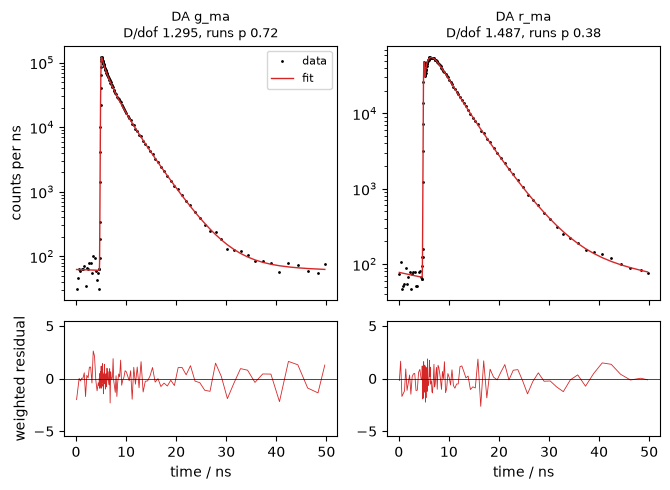

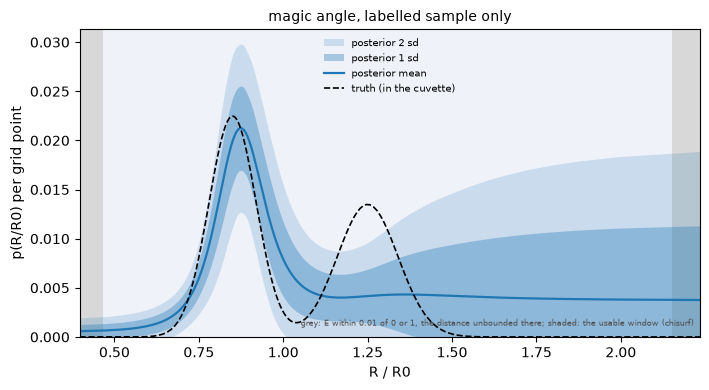

mean R/R0:  truth 0.9746   posterior 0.9795
the evidence mixture put weights [1.000e-04 2.000e-04 5.000e-04 1.400e-03 3.700e-03 1.010e-02 2.630e-02
 5.920e-02 1.153e-01 1.851e-01 2.377e-01 2.295e-01 1.310e-01] on log10 lambda = [-1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]


In [9]:
fig = P.plot_pR(model, post, p_true=p_true, title=exp.name)
plt.show()
m, lo1, hi1, lo2, hi2 = model['L'].delta_bands(None, post, rel, space='linear')
mean_true = float((p_true * rel).sum()); mean_fit = float((m * rel).sum())
print(f'mean R/R0:  truth {mean_true:.4f}   posterior {mean_fit:.4f}')
print(f'the evidence mixture put weights {np.round(post["weights"], 4)} on '
      f'log10 lambda = {post["lam_nodes"]}')


## The seven numbers not to quote

The identifiability table at the top of this notebook listed `r0_d`, `r0_a`,
`w_rho`, `w_rho_a`, `g`, `l1` and `l2` as moved by nothing in these data. The
fit converged and the posterior reports all seven. **Those seven numbers are the
prior**, and they would be the prior whatever the sample had done.

This is not a failure of the fit; it is the experiment. What is a failure is
reporting them without saying so, which is why the table is printed before the
fit rather than after it.

Note also how much larger the *measured* deviance reference is here than in
notebook 14. With two histograms and the same parameter dimension, the reported
degrees of freedom subtract far more than the penalised spline actually uses, so
the reference climbs well above one. Comparing this fit's D/dof with 1 would
have called a good fit bad.
